## Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Loading and Dataset

In [ ]:
df = pd.read_csv("Housing.csv")
df.head()

# **Helper Functions**

In [ ]:
def compute_error(X, y, w):
    """
    Calculating error of Predicted vs Actual
    """
    y_hat = X @ w
    return (y_hat - y)

In [ ]:
def add_bias(X):
    """
    Adding the intercept column
    """

    return np.column_stack([np.ones((X.shape[0], 1)), X])

In [ ]:
def encode(fb):
    df_enc = df.copy()

    for i in fb:
        if pd.api.types.is_string_dtype(df_enc[i]):
            df_enc[i] = df_enc[i].map({'yes': 1, 'no': 0})

    X = df_enc[fb].values.astype(float)
    Y = df_enc['price'].values.astype(float)

    X_train_raw, X_val_raw, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=True)

    return X_train_raw, X_val_raw, Y_train, Y_val

In [ ]:
def compute_loss(X, y, w):
    """
    Computing the MSE Loss using the following formula: (1 / (2m)) * sum((y_hat - y)^2)
    """

    m = len(y)
    error = compute_error(X, y, w)
    return ((1 / (2*m)) * np.sum((error) **2))

In [ ]:
def compute_gradient_descent(X, y, w):
    """
    Computing gradient descent wrt w using a tain/val split of 80/20
    """

    m = len(y)
    error = compute_error(X, y, w)

    return ((1/m) * (X.T @ error))

In [ ]:
def train_model(train_X, train_Y, val_X, val_Y, lr, n):
    """
    Training a linear regression model with gradient descent
    """

    # Initializing wieghts to 0
    w = np.zeros(train_X.shape[1])
    
    train_loss = []
    val_loss = []

    # Training Loop
    for i in range(n):
        gradient = compute_gradient_descent(train_X, train_Y, w)

        #Updating weights
        w = w - (lr * gradient)

        train_loss.append(compute_loss(train_X, train_Y, w))
        val_loss.append(compute_loss(val_X, val_Y, w))
    
    return w, np.array(train_loss), np.array(val_loss)

## Plot Helper Functions

In [ ]:
def plot_loss(train_loss, val_loss, lr, title):
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss,   label='Validation Loss')
    plt.xlabel('Iteration')
    plt.ylabel('MSE Loss')
    lbl = f'{title}' + (f'  (lr={lr})' if lr else '')
    plt.title(lbl)
    plt.legend()
    plt.tight_layout()
    plt.show()

# **Problem 1**

In [94]:
# Selecting required features for both parts of the Question
feature_a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

features_b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

# Converting into a 2D array
X_a = df[feature_a].values.astype(float)
Y_a = df['price'].values.astype(float)

# Splitting the dataset as required
X_train_1a_raw, X_val_1a_raw, Y_train_1a_raw, Y_val_1a_raw = train_test_split(X_a, Y_a, test_size=0.2, random_state=42, shuffle=True)

# Scaling to prevent divergence issue
X_scale = X_train_1a_raw.max(axis=0)
Y_scale = Y_train_1a_raw.max()

X_train_1a_raw = X_train_1a_raw / X_scale
X_val_1a_raw = X_val_1a_raw / X_scale
Y_train_1a = Y_train_1a_raw / Y_scale
Y_val_1a = Y_val_1a_raw / Y_scale

# Adding the bias column
X_train_1a = add_bias(X_train_1a_raw)
X_val_1a = add_bias(X_val_1a_raw)

print(f"Train: {X_train_1a.shape}, Val: {X_val_1a.shape}")

# Initializing lr and iterations

learning_rate = [0.1, 0.07, 0.05, 0.03, 0.01]
n = 2000

Train: (436, 6), Val: (109, 6)


## Part 1(a)

In [95]:
results_1a = {}

for i in learning_rate:
    w, train_loss, val_loss = train_model(X_train_1a, Y_train_1a, X_val_1a, Y_val_1a, i, n)

    results_1a[i] = (w, train_loss, val_loss)
    print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

lr=0.10 | Final Train Loss: 4.5069e-03 | Final Val Loss: 7.6522e-03
lr=0.07 | Final Train Loss: 4.5356e-03 | Final Val Loss: 7.7169e-03
lr=0.05 | Final Train Loss: 4.6033e-03 | Final Val Loss: 7.8515e-03
lr=0.03 | Final Train Loss: 4.8090e-03 | Final Val Loss: 8.2236e-03
lr=0.01 | Final Train Loss: 5.5188e-03 | Final Val Loss: 9.5074e-03


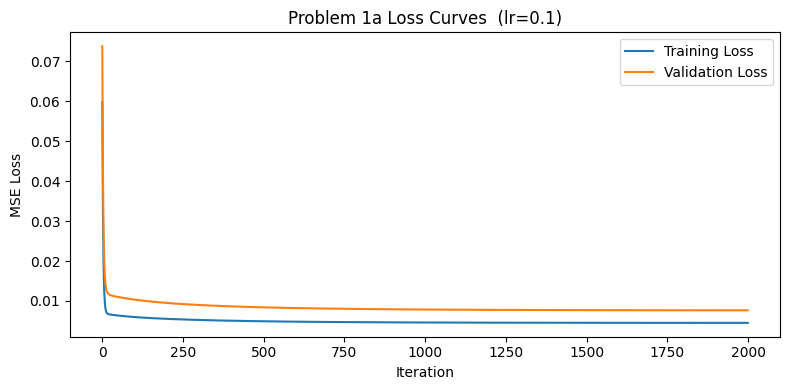

Best Learning Rate: 0.1
Learned Weights:
[0.01  0.394 0.09  0.354 0.164 0.087]


In [96]:
# Plotting the best learning rate 

# Picking the learning rate corresponding to lowest Validation loss
bestLR_1a = min(results_1a, key=lambda i: results_1a[i][2][-1])
w_1a, train_loss_1a, val_loss_1a = results_1a[bestLR_1a]

plot_loss(train_loss_1a, val_loss_1a, bestLR_1a, "Problem 1a Loss Curves")

print(f"Best Learning Rate: {bestLR_1a}")
print(f"Learned Weights:")
print(np.round(w_1a, 3))

## Part 1(b)

In [ ]:
X_train_1b_raw,  X_val_1b_raw, Y_train_1b_raw, Y_val_1b_raw = encode(features_b)

# Scaling to prevent divergence issue
X_scale = X_train_1b_raw.max(axis=0)
Y_scale = Y_train_1b_raw.max()

X_train_1b_raw = X_train_1b_raw / X_scale
X_val_1b_raw = X_val_1b_raw / X_scale
Y_train_1b = Y_train_1b_raw / Y_scale
Y_val_1b = Y_val_1b_raw / Y_scale

X_train_1b = add_bias(X_train_1b_raw)
X_val_1b = add_bias(X_val_1b_raw)

print(f"Train: {X_train_1b.shape}, Val: {X_val_1b.shape}")

results_1b = {}

for i in learning_rate:
    for i in learning_rate:
        w, train_loss, val_loss = train_model(X_train_1b, Y_train_1b, X_val_1b, Y_val_1b, i, n)

        results_1a[i] = (w, train_loss, val_loss)
        print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

Train: (436, 12), Val: (109, 12)
lr=0.10 | Final Train Loss: nan | Final Val Loss: nan
lr=0.07 | Final Train Loss: nan | Final Val Loss: nan
lr=0.05 | Final Train Loss: nan | Final Val Loss: nan
lr=0.03 | Final Train Loss: nan | Final Val Loss: nan
lr=0.01 | Final Train Loss: nan | Final Val Loss: nan
lr=0.10 | Final Train Loss: nan | Final Val Loss: nan
lr=0.07 | Final Train Loss: nan | Final Val Loss: nan
lr=0.05 | Final Train Loss: nan | Final Val Loss: nan


/tmp/ipykernel_29719/2797767291.py:8: RuntimeWarning: overflow encountered in square
  return ((1 / (2*m)) * np.sum((error) **2))
/tmp/ipykernel_29719/1067610049.py:9: RuntimeWarning: overflow encountered in matmul
  return ((1/m) * (X.T @ error))
/tmp/ipykernel_29719/1067610049.py:9: RuntimeWarning: invalid value encountered in matmul
  return ((1/m) * (X.T @ error))
/tmp/ipykernel_29719/3118633324.py:17: RuntimeWarning: invalid value encountered in subtract
  w = w - (lr * gradient)


lr=0.03 | Final Train Loss: nan | Final Val Loss: nan
lr=0.01 | Final Train Loss: nan | Final Val Loss: nan
lr=0.10 | Final Train Loss: nan | Final Val Loss: nan
lr=0.07 | Final Train Loss: nan | Final Val Loss: nan
lr=0.05 | Final Train Loss: nan | Final Val Loss: nan
lr=0.03 | Final Train Loss: nan | Final Val Loss: nan
lr=0.01 | Final Train Loss: nan | Final Val Loss: nan
lr=0.10 | Final Train Loss: nan | Final Val Loss: nan
lr=0.07 | Final Train Loss: nan | Final Val Loss: nan
lr=0.05 | Final Train Loss: nan | Final Val Loss: nan
lr=0.03 | Final Train Loss: nan | Final Val Loss: nan
lr=0.01 | Final Train Loss: nan | Final Val Loss: nan
lr=0.10 | Final Train Loss: nan | Final Val Loss: nan
lr=0.07 | Final Train Loss: nan | Final Val Loss: nan
lr=0.05 | Final Train Loss: nan | Final Val Loss: nan
lr=0.03 | Final Train Loss: nan | Final Val Loss: nan
lr=0.01 | Final Train Loss: nan | Final Val Loss: nan


In [ ]:
# Plotting the best learning rate 

# Picking the learning rate corresponding to lowest Validation loss
bestLR_1b = min(results_1a, key=lambda i: results_1b[i][2][-1])
w_1b, train_loss_1b, val_loss_1b = results_1b[bestLR_1b]

plot_loss(train_loss_1b, val_loss_1b, bestLR_1b, "Problem 1b Loss Curves")

print(f"Best Learning Rate: {bestLR_1b}")
print(f"Learned Weights:")
print(np.round(w_1b, 3))

In [ ]:
# Side-by-side loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_1a, label='1a Training', linestyle='--')
plt.plot(val_loss_1a, label='1a Validation',   linestyle='--')
plt.plot(train_loss_1b, label='1b Training')
plt.plot(val_loss_1b, label='1b Validation')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Parts 1a and 1b Comparison')
plt.legend()
plt.tight_layout()
plt.show()